In [ ]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.1/46.1 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.4 MB/s eta 0:00:00


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="c8DhOCVoqvy0NaZYpwXI")
project = rf.workspace("nitheshs-workspace-ybc0s").project("ppe-fruwx-tuv3m")
version = project.version(1)
dataset = version.download("yolov12")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.0/285.0 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 79.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 121.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 5.5 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 5.0.0.93
    Uninstalling opencv-python-headless-5.0.0.93:
      Successfully uninstalled opencv-python-headless-5.0.0.93
  Attempting uninstall: typer
    Found existing installation: typer 0.26.8
    Uninstalling typer-0.26.8:
      Successfully uninstalled typer-0.26.8
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to ppe-1 in yolov12:: 100%|██████████| 7431/7431 [00:03<00:00, 1880.40it/s]


In [ ]:
from ultralytics import YOLO
print("install success")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
install success


In [ ]:
model = YOLO("yolo11n.pt")

In [ ]:
result = model.train(data="/content/ppe-1/data.yaml",
                     epochs = 2,
                     imgsz = 416,
                     batch = 16,
                     name = "ppe_detector")

Ultralytics 8.4.105 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/ppe-1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=2, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=ppe_detector-2, nbs=64, nms=False, op

In [ ]:
from google.colab import files
upload = files.upload()
image_path = next(iter(upload))

Saving ppe.jpg to ppe.jpg


In [ ]:
from ultralytics import YOLO


model = YOLO("/content/runs/detect/ppe_detector-2/weights/best.pt")

result = model.predict(source = image_path, save = True, conf = 0.25)


image 1/1 /content/ppe.jpg: 288x416 1 helmet, 1 person, 1 vest, 107.9ms
Speed: 2.3ms preprocess, 107.9ms inference, 1.0ms postprocess per image at shape (1, 3, 288, 416)
Results saved to /content/runs/detect/predict-3


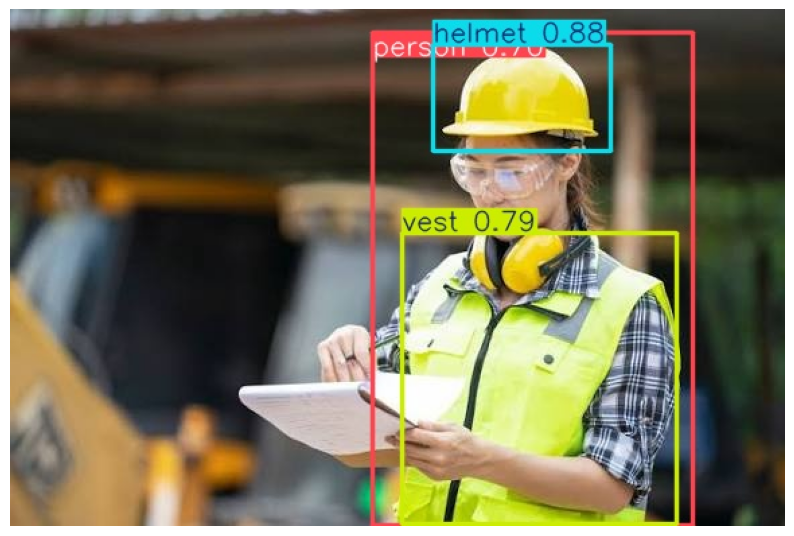

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import os


original_filename_base = os.path.splitext(os.path.basename(result[0].path))[0]
result_image = os.path.join(result[0].save_dir, original_filename_base + '.jpg')

image = Image.open(result_image)
plt.figure(figsize=(10,10))
plt.imshow(image)
plt.axis("off")
plt.show()

In [ ]:
!cp /content/runs/detect/ppe_detector-2/weights/best.pt /content/drive/MyDrive/niti22